# Stage 04 — a LEO pass through the run-spec driver

Stage 03 imaged one scenario with several sensors from a fixed position. This notebook moves the platform: a WORLDVIEW-2 pass over DIRSIG's Tahoe scene, authored as a recipe like the others, with the platform track propagated from a library TLE and three frames rendered 10 s apart around culmination. The steps:

1. **Compose.** `recipes/leo_pass_tahoe.yaml` names the scenario `tahoe_leo_pass` (the pass epoch and the observation) and the engine profile `tahoe_leo_pass`, whose `engine.motion` has kind `orbit`: a TLE, a propagator, a window, a waypoint spacing and a LookAt at a scene point (CONOPS and Guide §3.2, `proposed`).
2. **Validate.** The engine-free checks (schema, reference resolution with content hashes, library files), then admission with the DIRSIG dry run.
3. **Render.** Three 16 × 16 frames, one image and one truth file per frame.
4. **Check independently.** The platform position recovered from each frame's truth against the generated track; the track's ground track against one computed by the `sgp4` package with the GMST-1982 rotation; the frame-centre intercept against the LookAt target; the spacing of the frames against the platform speed.

---
# Setup

From a fresh clone, run `python scripts/bootstrap.py install` once (DIRSIG linked as `external/dirsig`, `dirfm` as `external/dirsig-file-maker`). This cell puts DIRSIG's `bin/` on `PATH`. Everything the notebook writes goes under `outputs/stage_04_leo_pass/`. The pass needs no network and no cached file: the TLE and the Earth-orientation tables are library files.

In [1]:
import os
import shutil
import sys
from pathlib import Path

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXTERNAL = PROJECT / "external"                       # populated by scripts/bootstrap.py install
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME") or EXTERNAL / "dirsig").resolve()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), \
    "DIRSIG binaries not on PATH: set DIRSIG_HOME or run scripts/bootstrap.py install"

try:
    import dirfm
except ImportError:
    sys.path.insert(0, str(EXTERNAL / "dirsig-file-maker"))
    import dirfm
try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

RECIPE = PROJECT / "manifold_run_specs" / "recipes" / "leo_pass_tahoe.yaml"
RUN_SPEC = PROJECT / "manifold_run_specs" / "leo_pass_tahoe.yaml"   # generated from RECIPE by scripts/compose.py
CONFIG_REPO = PROJECT / "manifold_config_repo"                      # engine assets, read-only
WORK = PROJECT / "outputs" / "stage_04_leo_pass"
if WORK.exists():
    shutil.rmtree(WORK)                               # our own directory
WORK.mkdir(parents=True)
print("DIRSIG_HOME :", DIRSIG_HOME)
print("dirfm       :", Path(dirfm.__file__).parent)
print("recipe      :", RECIPE.relative_to(PROJECT))
print("run spec    :", RUN_SPEC.relative_to(PROJECT))

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
dirfm       : /home/kevin-kearney/dev/dirsig-file-maker/dirfm
recipe      : manifold_run_specs/recipes/leo_pass_tahoe.yaml
run spec    : manifold_run_specs/leo_pass_tahoe.yaml


---
# Stage 0 — Compose

`compose` merges the recipe with its layers into one `run-spec/1` document; `explain` names the layer file and its sha256 for each member. The composed document is what `scripts/compose.py` wrote to `manifold_run_specs/leo_pass_tahoe.yaml`, byte for byte. The motion block is the new part: the TLE and the Earth-orientation tables are library refs with content hashes, and `up: along_track` is a named law, not a vector.

In [2]:
import yaml
from protodirsig.compose import compose, dump, explain

spec = compose(RECIPE)
assert dump(spec, "recipes/leo_pass_tahoe.yaml") == RUN_SPEC.read_text()
for member, src in explain(RECIPE).items():
    print(f"{member:24s} {src['layer']:46s} {(src['content_hash'] or '')[:19]}")
print()
print(yaml.safe_dump({"motion": spec["engine"]["motion"], "tasks": spec["engine"]["tasks"]}, sort_keys=False, width=120))
print("epoch:", spec["descriptor"]["collection"]["epoch"], "| settings:", spec["descriptor"]["settings"][0]["exposure_time"],
      spec["descriptor"]["settings"][0]["roi"])

spec_version             rules compose/1                                
descriptor.meta          recipes/leo_pass_tahoe.yaml                    sha256:2a88549c93bb
descriptor.origin        engine_profiles/tahoe_leo_pass.yaml            sha256:93b17ed6ee9d
descriptor.collection    scenarios/tahoe_leo_pass.yaml                  sha256:b434744ccb0d
descriptor.sensor        manifold_sensors/auror-nir.yaml                sha256:0f8c20403e1d
descriptor.settings      recipes/leo_pass_tahoe.yaml                    sha256:2a88549c93bb
descriptor.fidelity      recipes/leo_pass_tahoe.yaml                    sha256:2a88549c93bb
descriptor.extras        engine_profiles/tahoe_leo_pass.yaml            sha256:93b17ed6ee9d
engine                   engine_profiles/tahoe_leo_pass.yaml            sha256:93b17ed6ee9d

motion:
  kind: orbit
  orbit:
    tle:
      name: orbit/worldview2_35946.tle
      content_hash: sha256:3bfd197ff976c7a4dd3e990a696bf3e7544054900b2b0be9f7cb21680a5f4a90
    propagator: sky

The scenario's epoch is the start of a 120 s window centred on culmination (2026-09-26 18:51:25 UTC, 88.0° maximum elevation, sun 47.3° up). The pass was chosen at authoring time with `orbit.find_passes` and `orbit.choose_pass`; the JPL ephemeris they use for the sun is not a run input. The exposure is 10 µs, so the platform moves 7.6 cm while a frame integrates rather than 38 m at the 5 ms of the static runs; the truth-based position check below needs that.

---
# Stage 1 — Validate

The engine-free checks need no DIRSIG: the run-spec schema checks, resolution of every reference against its library with the stamped content hashes verified (including the TLE and the tables), and the library-file check (the platform template renders from the sensor, the TLE parses, the tables load). Admission through `LocalRegistry.submit` adds the DIRSIG dry run, which must schedule one capture per task window.

In [3]:
from protodirsig.registry import LocalRegistry
from protodirsig.run_spec import check_library_files, load_run_spec, resolve_auror_run
from protodirsig.simulation import schema_errors

loaded = load_run_spec(RUN_SPEC)
run = resolve_auror_run(loaded, RUN_SPEC, CONFIG_REPO)
print("schema        :", schema_errors(loaded) or "ok")
print("resolution    : ok,", run.motion_kind, "motion;", run.orbit["tle"].relative_to(PROJECT), "and",
      run.orbit["earth_orientation"].relative_to(PROJECT), "hash-verified")
print("library files :", check_library_files(loaded, run) or "ok")

submitted = LocalRegistry().submit(RUN_SPEC, CONFIG_REPO, WORK / "validate")
print("admission     :", submitted.verdict, submitted.checks)
assert submitted.accepted, submitted.reasons

Material [Dummy] ID has already been set to [N/A], can't override.


schema        : ok
resolution    : ok, orbit motion; manifold_config_repo/orbit/worldview2_35946.tle and manifold_config_repo/orbit/iers.npz hash-verified
library files : ok


admission     : accepted {'schema': True, 'resolution': True, 'execution': True}


---
# Stage 2 — Render three frames

`ground_track_check` (from `tests/test_leo_pass.py`, the same function the suite runs) submits the run, renders it and computes the independent checks. The platform template for the pass writes one image and one truth file per capture (`<base>-t<task>-c0000.img`); `RunResult.frames` lists them.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


submitted, rendered and checked in 3.4 s; propagator {'name': 'skyfield', 'version': '1.54', 'sgp4_version': '2.26', 'tag': 'skyfield_sgp4'}


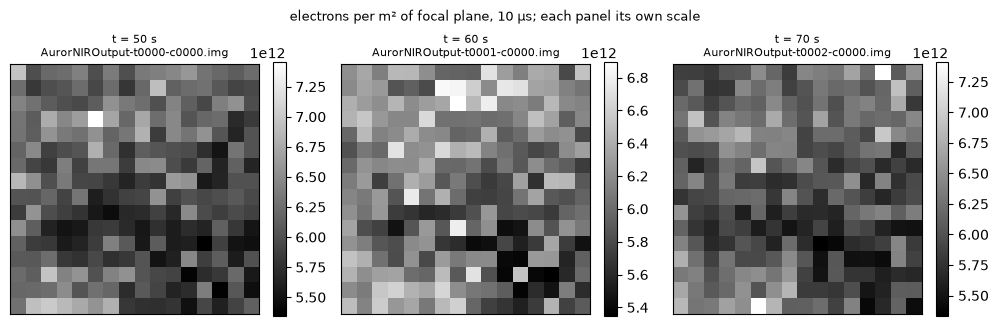

In [4]:
import time

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(PROJECT / "tests"))
from test_leo_pass import ground_track_check

t0 = time.perf_counter()
checks = ground_track_check(WORK / "pass")
print(f"submitted, rendered and checked in {time.perf_counter() - t0:.1f} s; propagator {checks['propagator']}")
out_dir = WORK / "pass" / "output"
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, f in zip(axes, checks["frames"]):
    hdr = (out_dir / f"{f['image']}.hdr").read_text()
    shape = [int(next(l.split("=")[1] for l in hdr.splitlines() if l.startswith(k))) for k in ("lines", "samples")]
    img = np.fromfile(out_dir / f["image"], dtype="<f8").reshape(shape)
    im = ax.imshow(img, cmap="gray")
    ax.set_title(f"t = {f['t_s']:.0f} s\n{f['image']}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("electrons per m² of focal plane, 10 µs; each panel its own scale", fontsize=9)
plt.tight_layout()

---
# Stage 3 — The independent checks

Each check uses something the generator did not produce. (a) The platform position is recovered from each frame's truth alone: every pixel gives the ECEF point its ray hit and the distance to it, and the sensor position is the least-squares solution of |S − Pᵢ| = dᵢ (`orbit.recover_position`). (b) The sub-satellite points of the generated track are compared with a track computed by the `sgp4` package directly, rotated to ITRS by the IAU-1982 GMST (`orbit.itrs_by_sgp4_gmst82`). (c) The frame-centre intercept (the mean of the four centre pixels' scene ENU hit points) is compared with the LookAt target, in units of the pixel footprint measured from the truth. (d) The recovered positions are compared with the platform speed times 10 s.

In [5]:
print(f"{'t s':>5s} {'recovered - track m':>20s} {'fit sigma m':>22s} {'centre ENU m':>24s} {'miss m':>7s} {'footprint m':>11s} {'miss px':>8s}")
for f in checks["frames"]:
    print(f"{f['t_s']:5.0f} {f['recovered_minus_track_m']:20.3f} {str([round(s, 3) for s in f['fit_sigma_m']]):>22s} "
          f"{str([round(v, 1) for v in f['centre_enu_m']]):>24s} {f['boresight_miss_m']:7.2f} {f['pixel_footprint_m']:11.2f} "
          f"{f['boresight_miss_m'] / f['pixel_footprint_m']:8.3f}")
print(f"(b) generated vs sgp4 + GMST-1982 ground track: max {checks['ground_track_diff_m'] * 100:.1f} cm")
for sep, want in zip(checks["separations_m"], checks["speed_x_10s_m"]):
    print(f"(d) frame separation {sep:10.2f} m   speed x 10 s {want:10.2f} m   difference {sep - want:+.2f} m")
assert all(f["recovered_minus_track_m"] < 1.0 and f["boresight_miss_m"] < f["pixel_footprint_m"] for f in checks["frames"])
assert checks["ground_track_diff_m"] < 0.1

  t s  recovered - track m            fit sigma m             centre ENU m  miss m footprint m  miss px
   50                0.384  [0.162, 0.129, 0.123]   [-400.6, 400.8, 133.4]    1.03       25.43    0.041
   60                0.026  [0.009, 0.007, 0.008]   [-398.5, 399.1, 133.2]    1.79       25.21    0.071
   70                0.285  [0.146, 0.109, 0.134]   [-400.2, 399.6, 133.6]    0.49       25.49    0.019
(b) generated vs sgp4 + GMST-1982 ground track: max 1.7 cm
(d) frame separation   75574.64 m   speed x 10 s   75575.31 m   difference -0.67 m
(d) frame separation   75577.21 m   speed x 10 s   75577.27 m   difference -0.07 m


The recovered positions agree with the generated track to well under a metre, best at culmination where the 16 × 16 window is seen most squarely; the fit's own sigma is printed beside each. The two ground tracks agree to centimetres, the level at which skyfield's and the hand-written Earth rotation differ. The frame centres land within a few percent of a pixel of the target, and the three positions are 75.6 km apart, the platform speed (7.56 km/s) times 10 s.

What this does not show: radiometry (the frames are 16 × 16 and the vehicle renders black in this band, as in the static runs), polar motion (not applied; metres at this altitude), and DIRSIG's native `sgp4` location engine, which applies no UT1 − UTC and is not used.